In [2]:
from IPython.display import display
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib


In [3]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df.dropna(inplace=True)
X = df.drop(["Churn", "CustomerID"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_test = y_test.astype(int)

In [4]:
num_cols = ["Age","Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"] 
cat_cols = ["Gender", "Subscription Type", "Contract Length"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

In [5]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(random_state=42))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     44943
           1       0.90      0.99      0.94     56099

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



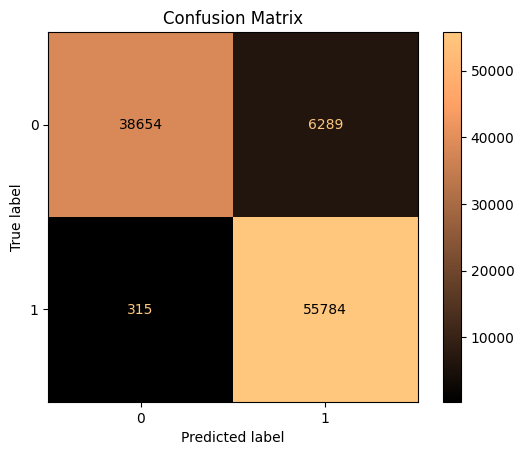

In [6]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="copper")
plt.title("Confusion Matrix")
plt.show()

In [7]:
joblib.dump(model, "model.pkl")

['model.pkl']